In [ ]:
from dotenv import load_dotenv
from langchain_teddynote import logging as langsmith_logging

# API KEY 정보로드
load_dotenv()
# Langsmith 로깅 설정
langsmith_logging.langsmith("RAG-EXAMPLE-LANGGRAPH")

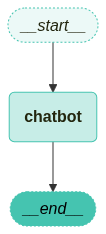

독산역 근처 맛집 TOP 10을 추천해드릴게요! 다양한 종류의 음식점들을 포함했으니 취향에 맞게 선택해 보세요.

1. **독산왕족발**  
   - 족발 전문점으로 쫄깃하고 담백한 족발이 인기입니다.

2. **청기와대**  
   - 한식 백반과 찌개류가 맛있는 곳으로, 깔끔한 반찬과 푸짐한 양이 특징입니다.

3. **독산곱창**  
   - 신선한 곱창과 막창을 숯불에 구워 먹을 수 있는 맛집입니다.

4. **홍콩반점 0410 독산점**  
   - 짬뽕과 짜장면 등 중화요리를 간편하게 즐길 수 있는 체인점입니다.

5. **카페 온더테이블**  
   - 분위기 좋은 카페로, 커피와 디저트가 맛있어 식사 후 디저트 코스로 추천합니다.

6. **독산동 김밥천국**  
   - 저렴하고 간편하게 한 끼 해결하기 좋은 김밥과 분식 전문점입니다.

7. **명동칼국수 독산점**  
   - 칼국수와 만두가 맛있는 곳으로, 따뜻한 국물이 생각날 때 좋습니다.

8. **바른치킨 독산점**  
   - 바삭하고 촉촉한 치킨을 즐길 수 있는 치킨 전문점입니다.

9. **독산동 순대국밥**  
   - 진한 국물과 푸짐한 순대가 일품인 순대국밥 전문점입니다.

10. **한방삼계탕 독산점**  
    - 건강한 삼계탕을 맛볼 수 있는 곳으로, 보양식이 필요할 때 추천합니다.

필요하시면 각 식당의 위치나 영업시간도 알려드릴 수 있습니다!


In [27]:
from typing import TypedDict, Annotated

from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langchain_teddynote.graphs import visualize_graph

### STEP 1. 상태(Stage) 정의
class State(TypedDict):
    # 메시지 정의(list type 이며 add_messages 함수를 사용하여 메시지를 추가)
    messages: Annotated[list, add_messages]

### STEP 2. 노드(Node) 정의
llm = ChatOpenAI(temperature=0, model="gpt-4.1-mini")

# 챗봇 함수 정의
def chatbot(state: State):
    # 메시지 호출 및 반환
    return {"messages": [llm.invoke(state["messages"])]}

### STEP 3. 그래프(Graph) 정의, 노드 추가
# 그래프 생성
graph_builder = StateGraph(State)

# 노드 이름, 함수 혹은 callable 객체를 인자로 받아 노드를 추가
graph_builder.add_node("chatbot", chatbot)

### STEP 4. 그래프 엣지(Edge) 추가
# 시작 노드에서 챗봇 노드로의 엣지 추가
graph_builder.add_edge(START, "chatbot")

# 그래프에 엣지 추가
graph_builder.add_edge("chatbot", END)

### STEP 5. 그래프 컴파일(compile)
# 그래프 컴파일
graph = graph_builder.compile()

# STEP 6. 그래프 시각화
visualize_graph(graph)

# 그래프 이벤트 스트리밍
question = "독산역 맛집 TOP 10 추천해줘."
for event in graph.stream({"messages": [("user", question)]}):
    # 이벤트 값 출력
    for value in event.values():
        print(value["messages"][-1].content)